<div style="text-align: center; font-family: Arial, sans-serif; margin-top: 50px;">
<h1 style="font-size: 36px; font-weight: bold; color: #4CAF50;">Mini-projet X - Méthode Monte Carlo</h1>
<h2 style="font-size: 20px; font-weight: bold; color: #4CAF50;">PHS3903</h2>
<h2 style="font-size: 20px; margin-bottom: 20px;">[Larose, Simon ; Gauthier, Émile ; Brunet-Mercier, Mathile]</h2>
<h2 style="font-size: 16px; margin-bottom: 10px;">[2256873; 2267504; 2293569]</h2>
<h2 style="font-size: 16px; margin-bottom: 10px;">[11/02/2026]</h2>
<h2 style="font-size: 16px; margin-bottom: 10px;">[Maksim Skorobagatiy; Jérémie Villeneuve; Sean Molesky]</h2>
</div>


### Calcul du volume d'une $N$-sphère (20 points)

### Introduction
Une $N$-sphère de rayon $R$ est définie comme l'ensemble des points situés à une distance inférieure ou égale à $R$ de l'origine dans un espace à $N$ dimensions. Si on utilise les coordonnées cartésiennes $(x_1, x_2, \dots, x_N)$ pour décrire un point, alors ce point est situé à l'intérieur de la $N$-sphère si le critère suivant est respecté :

$$
\sum_{i=1}^{N} x_i^2 \leq R^2, \quad N=1,2,\dots
$$

Voici quelques exemples de $N$-sphères afin de clarifier ce concept :
* Une 3-sphère est la sphère habituelle en trois dimensions. Son volume est la boule dont la sphère est le contour.
* Une 2-sphère est un cercle. Son volume est l'aire du disque circonscrit par le cercle.
* Une 1-sphère est formée de deux points sur une droite qui sont situés à égale distance de l'origine. Son volume est défini comme la longueur du segment.

Ce concept peut sembler abstrait, mais il apparaît naturellement en physique statistique quand on travaille dans l'espace de phase pour étudier les propriétés d'un ensemble de $N$ particules avec une énergie fixe (ex. : gaz idéal dans une boîte fermée). 

Dans ce mini-devoir, on vous demande de calculer le volume d'une $N$-sphère de rayon unitaire $R=1$ à l'aide de la méthode de Monte-Carlo vue en classe pour le calcul d'intégrales. Le résultat est déjà connu, à savoir :

$$
V_N = \frac{\pi^{N/2}}{\Gamma\left(\frac{N}{2} + 1\right)},
$$
où $\Gamma(x)$ est la fonction gamma, ce qui vous permettra de calculer l'erreur afin d'analyser le comportement de l'algorithme.

### Choix de la méthode de Monte-Carlo

**a) [4 pts]** Expliquer pourquoi les méthodes de Monte Carlo pour l'intégration sont avantageuses pour le calcul d'intégrales à $N$ dimensions lorsque $N$ devient grand.

### Réponse a):

Soit une intégrale en N dimensions à approximer numériquement :

$$
    V_N = \int f(x_1,x_2, ...,x_N) dx_1 dx_2...dx_N.
    
$$

La méthode de Monte-Carlo consiste à générer aléatoirement $N_{\text{tot}}$ points dans une région de volume $V_{\text{tot}}$. L'intégrale $V_N$ est alors approximée par :

$$
    V_N \approx \frac{N_{\text{in}}}{N_{\text{tot}}} V_{\text{tot}},
    
$$


où $N_{\text{in}}$ est le nombre de points sous la courbe $f(x)$.


L'erreur absolue $e$ associée à une méthode de Monte-Carlo est définie par la différence entre la valeur calculée numériquement et la valeur réelle de l'intégrale $V_N$ :

$$
    e = \left| \frac{N_{\text{in}}}{N_{\text{tot}}} V_{\text{tot}} - V_N \right|.
$$    

Puisque la méthode de Monte-Carlo est probabiliste, il est nécessaire d'effectuer plusieurs essais pour caractériser le comportement de l'erreur :

$$
    E ={N_{\text{{essais}}}}\sum_{i=0}^{N_{\text{{essais}}}} \left| \frac{N_{\text{in,i}}}{N_{\text{tot}}} V_{\text{tot}} - V_N \right|.
    
$$

Pour un grand nombre d'essais, l'erreur moyenne devient :

$$
    E \sim \frac{1}{\sqrt{N_{\text{tot}}}} .
    
$$

L'ordre de convergence de la méthode de Monte-Carlo est  $\mathcal{O}(N_{\text{tot}}^{-1/2})$ et il ne dépend pas de la dimensionnalité de l'intégrale à approximer. En comparaison, avec des méthodes d'approximation utilisant des maillages uniformes, l'ordre de convergence est  $\mathcal{O}(N_{\text{tot}}^{-r/N})$, où $N$ est le nombre de dimensions de l'intégrale à approximer et $r$ est un entier qui dépend de la méthode d'intégration numérique utilisée [1]. 


Ainsi, lorsque $N$ est grand, l'ordre de convergence des méthodes de Monte-Carlo est plus optimal que celui des méthodes conventionnelles utilisant un maillage uniforme. Les méthodes de Monte-Carlo sont donc avantageuses pour le calcul d’intégrales à $N$ dimensions lorsque $N$ devient grand.

[1] Dirk Nuyens : High-Dimensional Integration. CIME Summer School on High-Dimensional Approximation, 2024.

### Calcul du volume

**b) [6 pts]** Calculer le volume d'une $N$-sphère de rayon unitaire pour $N = \left\{3,6\right\}$. Pour chacune de ces $N$-sphères, calculer le résultat en faisant varier le nombre de points générés à chaque essai en utilisant les valeurs $N_{tot} = \left\{100,200,400,800,1600\right\}$. Générer 100 essais par simulation et utiliser la valeur moyenne du volume comme résultat. On vous demande donc de calculer dix valeurs de volume (cinq par $N$-sphère).

Présenter vos résultats sous forme de tableau, en fournissant une incertitude relative sur chaque résultat. Expliquer comment cette incertitude a été calculée.

### Réponse b):

In [98]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy import interpolate
from scipy import stats
import pandas as pd

# Paramètres géométriques
R = 1.0 # Rayon de la sphère

# Paramètres généraux de simulation
D_val = [3,6]  # Nombre de dimensions
Ntot_val = 100 * 2 ** (np.arange(0, 5, 1)) 
Ness = 100 # Nombre d'essais par simulation

a = 2  # Dimension de la boîte cubique dans laquelle les points aléatoires seront générés

# Boucle sur le nombre de dimensions
ND = len(D_val) # Nombre de valeurs de dimensions (N)
#print(ND) # Nombre de dimensions
NNtot = len(Ntot_val) # Nombre de valeurs de points totaux (N_tot)

V = np.zeros((ND, NNtot))  # Volumes calculés pour chaque série d'essais
err_rel = np.zeros((ND, NNtot)) # les erreurs relatives pour chaque série d'essais
inc_rel = np.zeros((ND, NNtot)) # l'incertitude relative pour chaque série d'essais

rows = [] # Formatage du tableau

for d in range(0, ND): # Boucle sur le nombre de dimensions
    D = D_val[d]  # Dimension
    Vtot = a**D # Volume du domaine
    Vth = np.pi**(D/2)/ sp.special.gamma(D/2 + 1) # Volume théorique

    for n in range(0, NNtot): # Boucle sur le nombre de points total

        Ntot = Ntot_val[n]  # Nombre de points

        Vind = np.zeros(Ness) # Volumes calculés pour chaque essai individuel
        Eind = np.zeros(Ness) # Erreur calculées pour chaque essai individuel

        for k in range(0,Ness): # Boucle sur les essais
            # Génération des nombres aléatoires (distribution uniforme)
            np.random.seed() # Initialise le générateur de nombres pseudo-aléatoires afin de ne pas toujours produire la même séquence à l'ouverture de Python...
            pts = a/2 * np.random.uniform(low=-1, high=1, size=(Ntot, D)) # Coordonnées des points
            
            # Calcul du volume
            Nint = 0 # Nombre de points à l'intérieur
            for i in range(0, Ntot):
                if np.linalg.norm(pts[i]) <= R: # Si le point est à l'intérieur de la sphère
                    Nint += 1
            
            Vind[k] = Nint / Ntot * Vtot # Volume calculé pour cet essai
            Eind[k] = (np.abs(Vind[k] - Vth) / Vth)*100
            
        V[d, n] = np.mean(Vind) # Volume moyen sur l'ensemble des essais

        inc_rel[d ,n] = np.std(Vind, ddof=1)/(V[d,n] * np.sqrt(Ness)) # Erreur relative de chacun des volumes calculés

        err_rel[d,n] = np.mean(Eind) # Erreur relative du volume calculée par rapport au volume théorique

        rows.append({'Nombre de dimensions':D, 'Nombre total de points par essai':Ntot_val[n],'Volume moyenné (u.a.)':V[d, n],'Incertitude relative sur le volume (s.a.)':inc_rel[d, n]})

df=pd.DataFrame(rows)
print(df.to_string(index=False))


 Nombre de dimensions  Nombre total de points par essai  Volume moyenné (u.a.)  Incertitude relative sur le volume (s.a.)
                    3                               100                4.22080                                   0.009036
                    3                               200                4.18040                                   0.005966
                    3                               400                4.16600                                   0.005124
                    3                               800                4.19450                                   0.003453
                    3                              1600                4.19805                                   0.001974
                    6                               100                5.33760                                   0.032924
                    6                               200                4.98560                                   0.024618
                    6   

### Réponse b):
La méthode de Monte-Carlo utilise des processus aléatoires afin d'approximer des résultats analytiques. Ainsi, pour calculer l'incertitude relative du volume calculé, il faut utiliser des techniques statistiques. Sachant que chaque essaei est indépendant et aléatoire, le comportement de la simulation respecte le théorème central limite puisque $N_{\text{essai}}=100$. Donc, l'expérience s'apparentera a une loi gaussienne où une moyenne et un écart-type peuvent être calculés. 


L'incertitude relative calculée sera une incertitude type sur la moyenne qui se calcule de la manière suivante:

$$
\sigma_V \approx \frac{\sigma(V_k)}{\bar{V}\sqrt{N_{\text{essai}}}}
$$

Ici $\sigma(V_k)$ est l'écart-type des volumes estimés par la méthode de Monte-Carlo. La formule exacte de l'incertitude type est donc:

$$
\sigma_V= \frac{1}{\bar{V}}\sqrt{\frac{\sum_{k=0}^{N_\text{essai}-1}(V_k-\bar{V})^2}{N_{\text{essai}}(N_{\text{essai}}-1)}}
$$
où ici $V_k$ est le volume calculé à l'essai $k$ et $\bar{V}$ est la moyenne des volumes sur les $N_{essai}$.

### Analyse de l'erreur

**c) [4 pts]** À l'aide des résultats précédents obtenus, tracer un graphique de l'erreur relative $E$ sur le volume calculé en fonction de $N_{tot}$ pour chaque $N$-sphère. (Vous tracerez donc deux séries de données sur le même graphique.) Utiliser une échelle qui permet de représenter facilement le comportement de l'erreur.

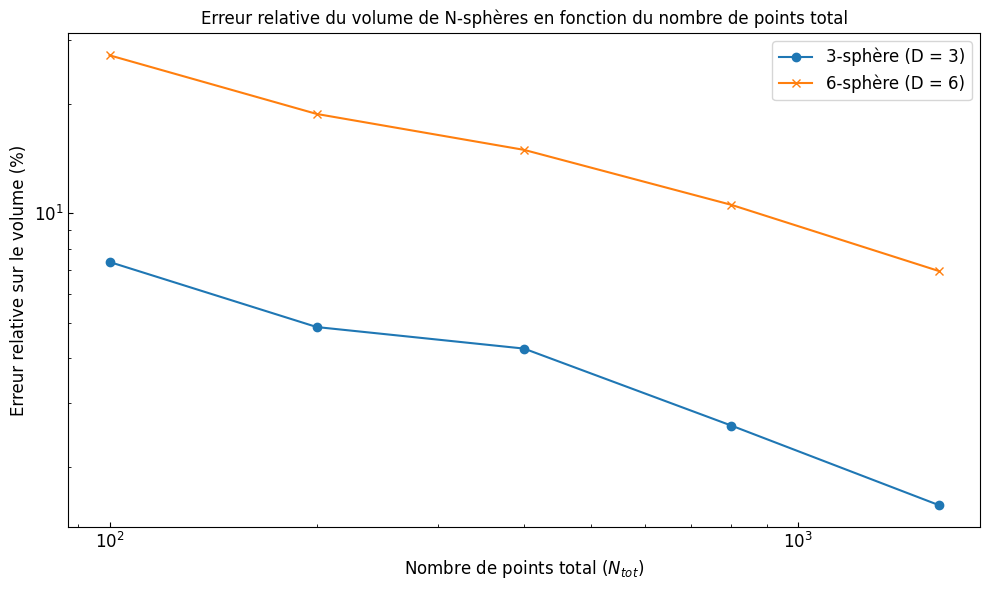

In [99]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

plt.plot(Ntot_val, err_rel[0], marker='o', label = "3-sphère (D = 3)")
plt.plot(Ntot_val, err_rel[1], marker='x', label = "6-sphère (D = 6)")
plt.legend(fontsize = 12)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Nombre de points total ($N_{tot}$)', fontsize = 12)
plt.ylabel('Erreur relative sur le volume (%)', fontsize = 12)   
plt.title('Erreur relative du volume de N-sphères en fonction du nombre de points total', fontsize = 12)
plt.tick_params(axis='both',direction='in', which='both', labelsize=12)
plt.tight_layout()
plt.show()

**d) [2 pts]** Déterminer le comportement de l'erreur relative en calculant l'exposant $p$ tel que :

$$
E = O(N_{tot}^p)
$$
pour chacune des deux $N$-sphères.

In [ ]:

def estimate_coef(x, y):
    # number of observations/points
    n = np.size(x)

    # mean of x and y vector
    m_x = np.mean(x)
    m_y = np.mean(y)

    # calculating cross-deviation and deviation about x
    SS_xy = np.sum(y*x) - n*m_y*m_x
    SS_xx = np.sum(x*x) - n*m_x*m_x

    # calculating regression coefficients
    b_1 = SS_xy / SS_xx
    b_0 = m_y - b_1*m_x

    return (b_0, b_1)

(logc,p)= estimate_coef(np.log(Ntot_val), np.log(err_rel[0]))
(logc2,p2)= estimate_coef(np.log(Ntot_val), np.log(err_rel[1]))
print("Estimation de l'ordre de convergence pour la 3-sphère (D=3): p = {}.".format(p))
print("Estimation de l'ordre de convergence pour la 6-sphère (D=6): p = {}.".format(p2))

Estimation de l'ordre de convergence pour la 3-sphère (D=3): p = -0.5355175078851819
Estimation de l'ordre de convergence pour la 6-sphère (D=6): p = -0.4782544981834528


**e) [4 pts]** Discuter des points suivants :
* Comment les valeurs de $p$ calculées se comparent-t-elle aux valeurs théoriques attendues ?
* La précision des résultats obtenus est-elle la même pour la 3-sphère et pour la 6-sphère ?
* Comment l'incertitude relative calculée en (b) se compare-t-elle à l'erreur relative ?

### Réponse e):

Les valeurs de $p$ obtenues sont $-0.536$ pour la 3-sphère et $p=-0.478$ pour la 6-sphère. Comme détaillé à la partie a), l'ordre de convergence théorique attendu pour la méthode de Monte-Carlo est de $p=-0.5$. L'erreur relative entre les valeurs de $p$ est de 7,1% pour la 3-sphère et 4,3% pour la 6-sphère. Ainsi, les valeurs de $p$ obtenues sont suffisament proches des valeurs théoriques attendues. 

Même si l'ordre de convergence est approximativement le même pour la 3-sphère et la 6-sphère, l'incertitude et l'erreur relative sont plus élevées d'un facteur se situant entre 3.5 et 4.5 pour la 6-sphère que pour la 3-sphère. Ainsi, la méthode de Monte-Carlo est plus précise pour le calcul du volume d'une sphère en 3 dimensions que pour celui d'une sphère en 6 dimensions. Ce résultat est attendu, puisque le rapport entre le volume total du domaine et le volume de la sphère est plus grand lorsqu'on augmente le nombre de dimensions. Ainsi, un plus grand nombre de points devient nécessaire pour obtenir une bonne approximation du volume.

L'erreur relative est environ 8 fois plus élevé que l'incertitude relative. L'erreur relative et l'incertitude relative diminue avec un ordre $p = -0.5$ par rapport au nombre de points par essai ($N_{\text{tot}}$). Puisque l'erreur et l'incertitude relative dépendent de la même façon de $N_{\text{tot}}$, le rapport entre les deux quantités est approximativement constant lorsque $N_{\text{tot}}$ varie. Cependant, l'incertitude relative diminue avec un ordre $p=-0.5$ par rapport au nombre d'essais par simulation ($N_{\text{essai}}$). Puisque l'erreur relative ne diminue pas avec $N_{\text{essai}}$, le ratio entre l'erreur et l'incertitude relative augmente lorsque $N_{\text{essai}}$ augmente.